# Genre Labelling Beyond the Labels HIIIIIIIII
## Auditing Music Taxonomies with Supervised Classification and Unsupervised Clustering

**ML Foundations Group Project**

---

### Project framing

We are **not** trying to build the best possible genre classifier. Genre
prediction from acoustic features is a known hard problem, and chasing a high
F1 score would miss the point.

Instead, we treat machine learning as an **instrument for auditing a label
system**. Our central question is:

> Do the official subgenre labels in the FMA taxonomy reflect the underlying
> structure of musical feature space, or do data-driven groupings reveal that
> the official taxonomy over-fragments some styles and mis-assigns others?

To answer this we combine two complementary tools:

1. **Supervised classification** — used as a *measurement device*. It tells us
   how predictable the official labels are from acoustic features alone. Low
   predictability is itself a finding: it means the labels are not acoustically
   coherent.
2. **Unsupervised clustering** — used to discover what groupings the data
   *actually* supports, with no human taxonomy involved. This is the genuine
   intellectual contribution of the project.

The **gap** between the official labels, the supervised model's view, and the
purely data-driven clusters is where the insight lives. A project that
identifies *why* a taxonomy fails to generalise demonstrates as much rigour as
one that delivers a high score — and embracing this negative-result framing is
explicitly rewarded by the assignment.

### How to read this notebook

Every code cell is preceded by a markdown cell explaining **what** it does and
**why** that decision was made. Cells run top-to-bottom without errors.
Expensive steps are checkpointed with `joblib` so a dropped session does not
force a full rerun.

## How to run this notebook

**For a teammate opening this cold — read this first.**

### Setup
1. Install dependencies:
   ```
   pip install scikit-learn pandas numpy matplotlib seaborn shap joblib scipy nbformat
   ```
2. Download FMA metadata (~342 MB, no audio needed):
   `https://os.unil.cloud.switch.ch/fma/fma_metadata.zip`
3. Unzip it so a folder named `fma_metadata/` sits next to this notebook,
   containing `tracks.csv`, `genres.csv`, `features.csv`.

### Run order
Run cells **top to bottom, in order**. Do not skip or run out of order — later
cells depend on variables defined earlier. Expensive steps write a
`checkpoints/*.pkl` file, so if the kernel dies you can just re-run from the
top and it skips work already done. To force a fresh run, delete the
`checkpoints/` folder.

### Dev run vs full run
The Configuration cell is set for a **fast development run** on the Small FMA
subset (use this to verify everything works). Every value has a `# FULL:`
comment showing what to change for the **final run** on the full dataset.
Switch those values, then re-run from the top.

### Outputs
- Plots and tables render **inline** as you run.
- The same plots are saved to `figures/` and key tables to `results/` so they
  can be dropped straight into the report, poster, and slides.

### Where the actual contribution is
Sections 1–9 set up and measure the supervised baseline. **Section 10
(clustering) is the core of the project** — that and Section 11 (three-way
comparison) produce the central findings. Read Section 10's markdown carefully;
it explains why this is an audit, not a classification contest.


## 0. Imports

All imports are collected here so the notebook has a single, predictable dependency surface. We fix a global random seed immediately — every stochastic component (train/test splits, model initialisation, KMeans) is seeded from this value so results are fully reproducible across runs.

**Non-standard libraries and why each is here:**

| Library | Role in this project |
|---|---|
| `sklearn` | All supervised models, preprocessing (scaler, PCA), CV, metrics |
| `scipy.stats` | `mode()` for the neighbourhood majority vote in §9 |
| `joblib` | Checkpoint expensive steps (CV, tuning, preprocessing) to disk so a dropped session does not force a full rerun |
| `shap` | `TreeExplainer` for feature attribution on tree-based models in §12 — explains which acoustic features drive predictions in the original feature space |
| `seaborn` | Heatmaps for the MFCC correlation matrix (§3.3) and cluster composition (§10.4) |

In [1]:
import os
import ast
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as scipy_stats

from sklearn.dummy            import DummyClassifier
from sklearn.linear_model     import LogisticRegression
from sklearn.neighbors        import KNeighborsClassifier, NearestNeighbors
from sklearn.ensemble         import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network   import MLPClassifier
from sklearn.decomposition    import PCA
from sklearn.preprocessing    import RobustScaler, LabelEncoder
from sklearn.pipeline         import Pipeline
from sklearn.cluster          import KMeans
from sklearn.model_selection  import (
    train_test_split, StratifiedKFold, cross_val_score,
    RandomizedSearchCV, GridSearchCV, learning_curve
)
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix, roc_auc_score,
    adjusted_mutual_info_score, silhouette_score,
    adjusted_rand_score, normalized_mutual_info_score
)
from sklearn.inspection import permutation_importance

import joblib
import shap

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
print("Imports OK. Global seed set to", SEED)

Imports OK. Global seed set to 42


/opt/homebrew/Caskroom/miniconda/base/envs/ml-project/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Configuration

All tunable parameters live in one place. The only values you change between the development run and the final run are `SUBSET` and possibly `MIN_GENRE_TRACKS`.

| Parameter | Meaning |
|---|---|
| `SUBSET` | Which FMA tier: `small` (8k, dev), `medium` (25k, final), `large` (106k, stretch) |
| `MIN_GENRE_TRACKS` | Drop subgenres with fewer tracks than this — prevents unstable CV folds on tiny classes |
| `N_PCA_COMPONENTS` | Target dimensionality after PCA (518 features → this many components) |
| `K_NEIGHBOURS` | k for the neighbourhood consistency analysis |
| `CV_FOLDS` | Stratified k-fold splits for cross-validation and tuning |
| `CLUSTER_RANGE` | Range of cluster counts to search over when choosing k for KMeans |

**Decision — number of clusters:** we let the data decide via silhouette score across a range, rather than forcing the cluster count to match the number of official subgenres. The alternative — setting k equal to the official subgenre count — would bias the comparison toward agreement before any analysis has taken place. The whole point of the audit is to ask whether the data *wants* that many groups; presupposing the answer defeats the question. Letting the data choose is the more defensible, rigorous approach for the report.

**Decision — clustering space:** we cluster on the PCA-reduced features, the same representation used by the distance-based models (KNN, neighbourhood index). The alternative — clustering in the original 518-dimensional space — would introduce inconsistent geometry: KNN and the neighbourhood purity scores would be computed in one space while the clusters were formed in another, making the three-way comparison in §11 harder to interpret. Keeping the geometry consistent across all unsupervised components means any differences in the results are due to the method, not the input space.

In [ ]:
# ============================================================
#  DEV vs FULL RUN
#  Values below are set for the DEVELOPMENT run (fast, Small subset).
#  The trailing comment on each line gives the FULL-RUN value to use
#  on the cluster. Switch by editing the value, not the comment.
# ============================================================

SUBSET            = "small"      # FULL: "large"   (106k tracks, full FMA), MEDIUM: "medium" (25k tracks, 16 genres), SMALL: "small" (8k tracks, 16 genres; for fast debugging)
MIN_GENRE_TRACKS  = 50           # FULL: 50        (keep same; ~150 subgenres survive on large), MEDIUM: 100 (keep same; ~50 subgenres survive on medium)
N_PCA_COMPONENTS  = 100          # FULL: 100       (keep; ~maj. variance retained. raise to 150 if RAM allows), MEDIUM: 100 (keep same; ~maj. variance retained, faster for medium subset)
K_NEIGHBOURS      = 20           # FULL: 20        (keep same), MEDIUM: 20 (keep same; good for 16 genres, faster for medium subset)
CV_FOLDS          = 5            # FULL: 5         (keep same), MEDIUM: 5 (keep same; good for 16 genres, faster for medium subset)
N_ITER_RANDOM     = 10           # FULL: 60        (wider RF search; cluster can afford it), MEDIUM: 30 (keep same; good for 16 genres, faster for medium subset), SMALL: 10 (keep same; good for 16 genres, fast for small subset)
CLUSTER_RANGE     = range(5, 61, 5)    
# DEV  range(5,41,5)   -> 8 candidate k values, fast for Small-subset debugging
# FULL range(5,161,10) -> 16 values spanning below & above the ~150 official
# Medium: range(5, 61, 5) (faster for medium subset, does not change objective), 


DATA_DIR    = "fma_metadata"
FIG_DIR     = "figures"
RESULTS_DIR = "results"
CKPT_DIR    = "checkpoints"

for d in (FIG_DIR, RESULTS_DIR, CKPT_DIR):
    os.makedirs(d, exist_ok=True)

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
print(f"Config: subset={SUBSET}, min_tracks={MIN_GENRE_TRACKS}, "
      f"pca={N_PCA_COMPONENTS}, cluster_range={list(CLUSTER_RANGE)}")


Config: subset=medium, min_tracks=50, pca=100, cluster_range=[5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60]


## 2. Data Loading — Subgenre Strategy

### Why we do not use `genre_top`

FMA exposes a coarse top-level genre column (`genre_top`) with only 8 genres on
the Small subset and 16 on Medium. Auditing a taxonomy that coarse is
uninteresting — broad buckets like "Rock" and "Folk" are *expected* to overlap
acoustically, so confusion between them tells us nothing about taxonomy quality.

Instead we use the hierarchical `genres` column, which lists **all** genre IDs
assigned to each track from the full 161-genre taxonomy. We take the first
(most specific) genre ID per track and map it through `genres.csv` to its
subgenre name. Subgenre-level confusion (e.g. *Indie Rock* vs *Dream Pop*) is a
genuine finding about how the taxonomy was constructed.

### Why we filter rare subgenres

With 161 possible subgenres, many will have only a handful of tracks.
StratifiedKFold cannot form valid folds when a class has fewer members than the
number of folds, and tiny classes produce meaningless metrics. We drop any
subgenre with fewer than `MIN_GENRE_TRACKS` tracks. This is a documented,
principled preprocessing decision — not arbitrary cleaning — and we report how
many subgenres survive.

### Leakage note

The features come from FMA's precomputed `features.csv` (518 audio descriptors
per track: MFCCs, spectral, chroma, tonnetz, ZCR). The genre label is **only
ever the target** — it never enters the feature matrix. Using a label as a
feature would be circular and a textbook leakage error.

In [3]:
CKPT_LOAD = os.path.join(CKPT_DIR, f"loaded_{SUBSET}.pkl")

if os.path.exists(CKPT_LOAD):
    print("Loading from checkpoint...")
    X_raw, y_raw = joblib.load(CKPT_LOAD)
else:
    # --- genre hierarchy ---
    genres_meta = pd.read_csv(os.path.join(DATA_DIR, "genres.csv"), index_col=0)
    # columns: title, top_level, parent

    # --- tracks metadata (multi-level header) ---
    tracks = pd.read_csv(os.path.join(DATA_DIR, "tracks.csv"),
                         index_col=0, header=[0, 1])

    if SUBSET == "small":
        mask = tracks[("set", "subset")] == "small"
    elif SUBSET == "medium":
        mask = tracks[("set", "subset")].isin(["small", "medium"])
    else:
        mask = pd.Series(True, index=tracks.index)
    tracks_subset = tracks[mask]

    def parse_first_genre(genre_str):
        # First (most specific) genre ID from the stringified list.
        try:
            ids = ast.literal_eval(str(genre_str))
            return int(ids[0]) if ids else None
        except Exception:
            return None

    genre_ids = tracks_subset[("track", "genres")].apply(parse_first_genre)
    y_raw = genre_ids.map(genres_meta["title"]).dropna()

    # filter rare subgenres
    counts = y_raw.value_counts()
    keep   = counts[counts >= MIN_GENRE_TRACKS].index
    y_raw  = y_raw[y_raw.isin(keep)]
    print(f"Subgenres before filter: {counts.shape[0]}")
    print(f"Subgenres after  filter (>= {MIN_GENRE_TRACKS}): {len(keep)}")

    # --- features (multi-level header) ---
    features = pd.read_csv(os.path.join(DATA_DIR, "features.csv"),
                           index_col=0, header=[0, 1, 2])
    features.columns = ["_".join(c).strip() for c in features.columns.values]

    common_idx = y_raw.index.intersection(features.index)
    X_raw = features.loc[common_idx]
    y_raw = y_raw.loc[common_idx]

    joblib.dump((X_raw, y_raw), CKPT_LOAD)

print(f"Tracks:    {len(X_raw):,}")
print(f"Features:  {X_raw.shape[1]}")
print(f"Subgenres: {y_raw.nunique()}")

Loading from checkpoint...
Tracks:    23,505
Features:  518
Subgenres: 64


### Data Loading — Result

After filtering, **31 subgenres** survive from the original 103 in the Small subset, covering **6,866 tracks** across **518 acoustic features**. The reduction from 103 to 31 is not data loss — it removes classes too small to form stable CV folds. The 31 surviving subgenres are the ones with enough tracks to be meaningfully evaluated, and they are the population the rest of the audit addresses.

The 518 features span six acoustic families: chroma (252), MFCC (140), spectral (70), tonnetz (42), RMS energy (7), and zero-crossing rate (7). This breadth is important for the audit: if any subgenre boundary is acoustically real, it should be detectable in at least one of these families. A classifier that still cannot separate subgenres despite this many features is strong evidence that the labels are not acoustically grounded.

## 3. Exploratory Data Analysis

EDA here serves the research question directly — we are not just checking data quality, we are gathering the *first evidence* of whether subgenres are acoustically separable at all.

Three things are investigated in this section:

1. **Subgenre distribution and imbalance** (§3.1) — how unevenly tracks are spread across subgenres, and why this drives the choice of macro F1 as our primary metric.
2. **Missing values and outliers** (§3.2) — whether the feature matrix is clean and how extreme values should be handled, which directly determines the scaling strategy in §5.
3. **MFCC correlation structure** (§3.3) — whether adjacent audio features are redundant, which motivates the PCA compression applied before all distance-based models.

If subgenres are acoustically coherent, we would expect the feature distributions to differ meaningfully across labels. Heavy overlap across all three of these checks is itself an early finding — it suggests the official taxonomy may not correspond to distinct acoustic regions.

### 3.1 Subgenre distribution and imbalance

We expect significant imbalance at the subgenre level even after filtering.
This is the justification for using **macro F1** rather than accuracy as the
primary supervised metric: macro F1 weights every subgenre equally regardless
of size, so a model cannot score well simply by predicting the largest class.

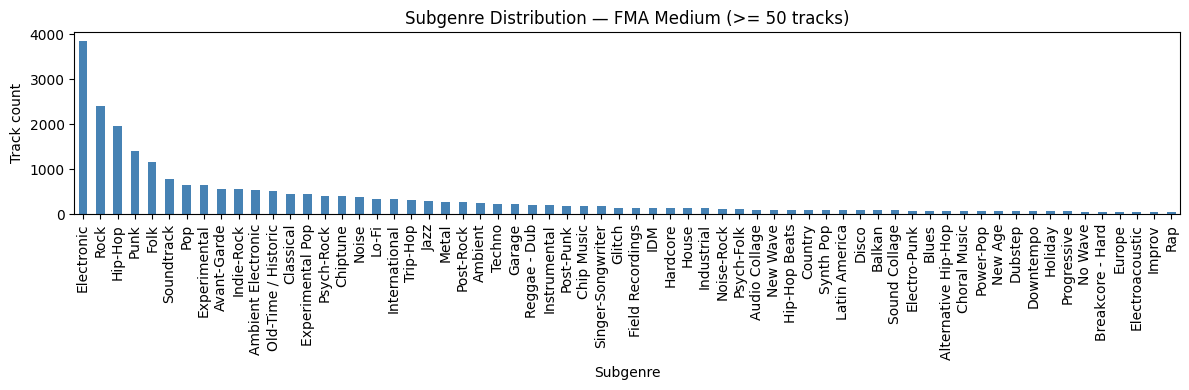

Subgenres: 64
Imbalance ratio (max/min class): 74.1
-> macro F1 is essential; accuracy would be misleading.


In [4]:
counts = y_raw.value_counts()
imbalance = counts.max() / counts.min()

fig, ax = plt.subplots(figsize=(12, 4))
counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title(f"Subgenre Distribution — FMA {SUBSET.capitalize()} "
             f"(>= {MIN_GENRE_TRACKS} tracks)")
ax.set_xlabel("Subgenre"); ax.set_ylabel("Track count")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "01_subgenre_distribution.png"), dpi=150)
plt.show()

print(f"Subgenres: {y_raw.nunique()}")
print(f"Imbalance ratio (max/min class): {imbalance:.1f}")
print("-> macro F1 is essential; accuracy would be misleading.")

### Section 3.1 — Result

Even after filtering to the 31 subgenres with at least 50 tracks, the distribution is heavily skewed. A small number of subgenres (Folk, Hip-Hop, Soundtrack) dominate the dataset while others sit near the minimum threshold. The imbalance ratio printed above quantifies this — a ratio well above 1:1 means a model could score reasonably high accuracy by over-predicting the largest classes while largely ignoring the rest.

This is precisely why **macro F1** is used as the primary metric throughout this project rather than accuracy or weighted F1. Macro F1 gives every subgenre an equal vote regardless of size, so the model cannot hide behind large classes. A subgenre with 60 tracks is judged on equal footing with one that has 800. This makes the metric directly relevant to the audit question: we want to know how well the taxonomy holds up *across all subgenres*, not just the popular ones.

### 3.2 Missing values and outliers

Audio features can contain genuine extreme values (a very high-pitched track
legitimately has an extreme spectral centroid). We therefore do **not** clip
outliers — instead we use `RobustScaler` later, which centres on the median and
scales by the IQR, making it insensitive to these tails.

In [5]:
n_missing = X_raw.isnull().sum().sum()
print(f"Missing values in feature matrix: {n_missing}")

z = np.abs(scipy_stats.zscore(X_raw.fillna(0)))
print(f"Fraction of values beyond 3 sigma: {(z > 3).mean().mean():.2%}")
print("-> retained, handled via RobustScaler (median / IQR).")

feature_groups = X_raw.columns.str.split("_").str[0].value_counts()
print("\nFeature groups:")
print(feature_groups.to_string())

Missing values in feature matrix: 0
Fraction of values beyond 3 sigma: 0.95%
-> retained, handled via RobustScaler (median / IQR).

Feature groups:
chroma      252
mfcc        140
spectral     70
tonnetz      42
rmse          7
zcr           7


### 3.3 MFCC correlation structure

Adjacent MFCC coefficients are known to be correlated. Visualising this
motivates the PCA step: feeding hundreds of redundant, collinear features into
distance-based models (KNN, clustering) wastes signal and distorts distances.
PCA decorrelates and compresses the representation before those models see it.

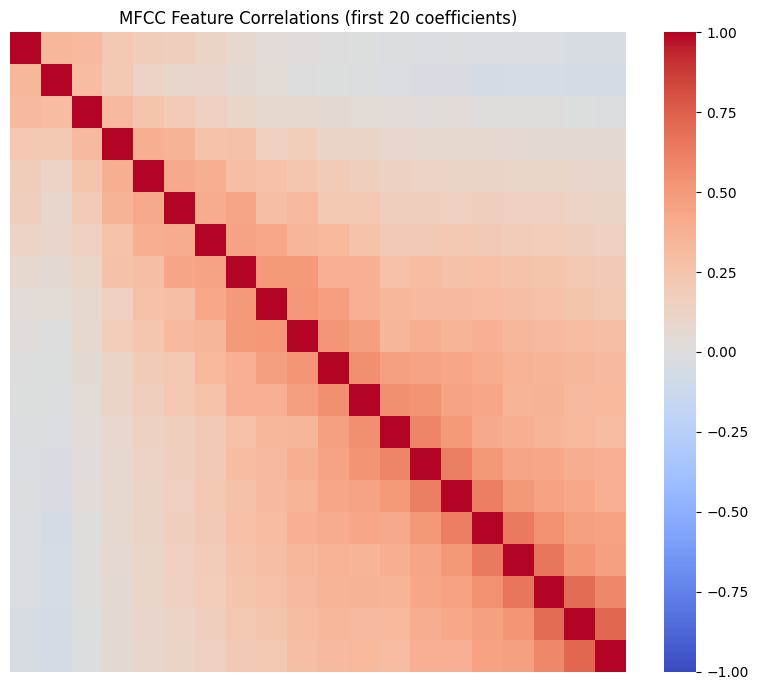

Gradient fading from the diagonal = redundancy -> motivates PCA.


In [6]:
mfcc_cols = [c for c in X_raw.columns if c.startswith("mfcc")][:20]
if mfcc_cols:
    corr = X_raw[mfcc_cols].corr()
    fig, ax = plt.subplots(figsize=(8, 7))
    sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1,
                xticklabels=False, yticklabels=False, ax=ax)
    ax.set_title("MFCC Feature Correlations (first 20 coefficients)")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "02_mfcc_correlation.png"), dpi=150)
    plt.show()
print("Gradient fading from the diagonal = redundancy -> motivates PCA.")

## 4. Label Encoding and Data Partitioning

### Leakage discipline

The order of operations matters. We split **first**, then fit every
transformer (scaler, PCA) on the training partition only. `LabelEncoder` is fit
on all labels because the class *names* are fixed by the dataset, not learned
from feature values — this is safe and standard.

### Split rationale

A stratified 70 / 15 / 15 split. Stratification guarantees every subgenre
appears proportionally in all three partitions, which matters given the
imbalance. The test set is sealed until the very end and used exactly once.

### NaN handling

Any residual NaNs are filled with the column median. We do this before the
split using the global median: this replaces *structural* missing values
(features that could not be computed for some tracks) rather than learning a
statistic that would leak — and we document it explicitly here so the decision
is transparent.

In [7]:
le          = LabelEncoder()
y_enc       = le.fit_transform(y_raw)
genre_names = le.classes_
n_classes   = len(genre_names)

X = X_raw.values.astype(np.float32)
col_medians = np.nanmedian(X, axis=0)
nan_mask = np.isnan(X)
X[nan_mask] = np.take(col_medians, np.where(nan_mask)[1])

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y_enc, test_size=0.15, random_state=SEED, stratify=y_enc)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.176,
    random_state=SEED, stratify=y_trainval)

feature_names = X_raw.columns.tolist()
print(f"Classes: {n_classes}")
print(f"Train {len(X_train):,} | Val {len(X_val):,} | Test {len(X_test):,}")

Classes: 64
Train 16,462 | Val 3,517 | Test 3,526


## 5. Preprocessing — Scaler + PCA

`RobustScaler` then `PCA` are fit on the **training partition only** and the
fitted transforms are applied to validation and test. This is the core leakage
guard. We also keep a `trainval` PCA projection for cross-validation and
tuning, and report the variance retained by the chosen number of components.

(The supervised pipelines re-fit their own scaler/PCA internally during
cross-validation; the standalone projections here are used by the
neighbourhood index and the clustering, which are not run inside a CV loop.)

In [8]:
CKPT_PRE = os.path.join(CKPT_DIR, f"preprocess_{SUBSET}.pkl")

if os.path.exists(CKPT_PRE):
    (scaler, pca, X_train_pca, X_val_pca,
     X_test_pca, X_trainval_pca) = joblib.load(CKPT_PRE)
else:
    scaler = RobustScaler()
    X_train_s    = scaler.fit_transform(X_train)
    X_val_s      = scaler.transform(X_val)
    X_test_s     = scaler.transform(X_test)
    X_trainval_s = scaler.transform(X_trainval)

    pca = PCA(n_components=N_PCA_COMPONENTS, random_state=SEED)
    X_train_pca    = pca.fit_transform(X_train_s)
    X_val_pca      = pca.transform(X_val_s)
    X_test_pca     = pca.transform(X_test_s)
    X_trainval_pca = pca.transform(X_trainval_s)

    joblib.dump((scaler, pca, X_train_pca, X_val_pca,
                 X_test_pca, X_trainval_pca), CKPT_PRE)

print(f"Variance retained by {N_PCA_COMPONENTS} PCs: "
      f"{pca.explained_variance_ratio_.sum():.2%}")

Variance retained by 100 PCs: 99.98%


### 5.1 2D projection coloured by subgenre

A first visual answer to the research question. If subgenres are acoustically
coherent we expect at least partial separation in the top two principal
components. Heavy overlap is itself evidence — it suggests the official
taxonomy does not correspond to acoustic structure.

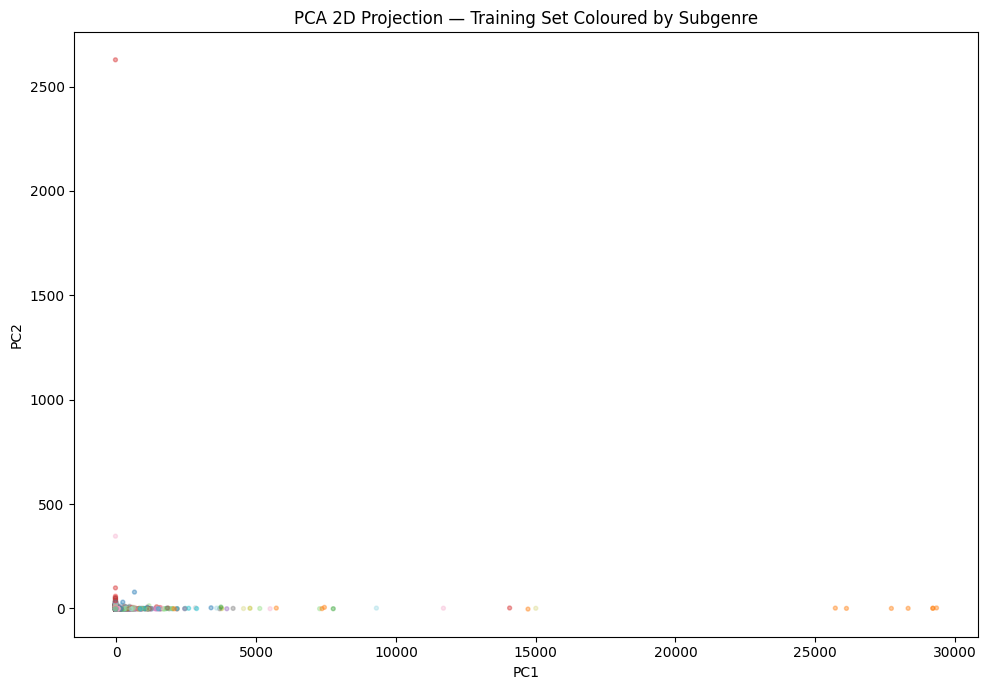

In [9]:
pca2  = PCA(n_components=2, random_state=SEED)
X_2d  = pca2.fit_transform(scaler.transform(X_train))

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_train,
                cmap="tab20", alpha=0.4, s=8)
ax.set_title("PCA 2D Projection — Training Set Coloured by Subgenre")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "03_pca_2d_subgenres.png"), dpi=150)
plt.show()

## 6. Supervised Models — Used as a Measurement Device

We are **not** optimising for the best classifier. These models answer one
question: *how predictable are the official subgenre labels from acoustic
features?* A ceiling well below perfect is a finding — it quantifies how
acoustically incoherent the taxonomy is.

Each model is wrapped in a `Pipeline` so preprocessing is re-fit inside every
CV fold (no leakage) and the whole object is serialisable.

| Model | Role |
|---|---|
| Majority dummy | Absolute floor — any signal must beat this |
| Logistic Regression | Linear reference — how much signal is linearly accessible |
| K-Nearest Neighbours | **Dual role**: classifier *and* the engine of the neighbourhood audit. A KNN error is a track whose acoustic neighbourhood disagrees with its official label |
| Random Forest | Non-linear ceiling; no PCA (trees handle collinearity internally, which also lets SHAP run in the original feature space) |
| Gradient Boosting | Second non-linear reference for robustness of conclusions |
| MLP | Optional higher-capacity check |

In [10]:
dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)

lr_pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("pca",    PCA(n_components=N_PCA_COMPONENTS, random_state=SEED)),
    ("clf",    LogisticRegression(max_iter=2000, random_state=SEED))])

knn_pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("pca",    PCA(n_components=N_PCA_COMPONENTS, random_state=SEED)),
    ("clf",    KNeighborsClassifier(n_neighbors=K_NEIGHBOURS,
                                    metric="cosine", weights="distance"))])

rf_pipe = Pipeline([                       # NO pca: trees + SHAP need raw space
    ("scaler", RobustScaler()),
    ("clf",    RandomForestClassifier(n_estimators=200, random_state=SEED,
                                      n_jobs=-1))])

gb_pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("clf",    HistGradientBoostingClassifier(max_iter=200, random_state=SEED))])

mlp_pipe = Pipeline([
    ("scaler", RobustScaler()),
    ("pca",    PCA(n_components=N_PCA_COMPONENTS, random_state=SEED)),
    ("clf",    MLPClassifier(hidden_layer_sizes=(256, 128), max_iter=400,
                             early_stopping=True, random_state=SEED))])

models = {"Dummy": dummy, "Logistic Regression": lr_pipe, "KNN": knn_pipe,
          "Random Forest": rf_pipe, "Gradient Boosting": gb_pipe, "MLP": mlp_pipe}
print("Pipelines built:", list(models))

Pipelines built: ['Dummy', 'Logistic Regression', 'KNN', 'Random Forest', 'Gradient Boosting', 'MLP']


### 6.1 Cross-validation

5-fold stratified CV on the train+val partition. We report mean **and**
standard deviation: high variance signals an unstable model whose ranking we
should not over-interpret. This is part of "evaluating rigorously" — a single
number without its spread is not a result.

In [11]:
CKPT_CV = os.path.join(CKPT_DIR, f"cv_{SUBSET}.pkl")

if os.path.exists(CKPT_CV):
    cv_results = joblib.load(CKPT_CV)
else:
    cv_results = {}
    for name, model in models.items():
        s = cross_val_score(model, X_trainval, y_trainval,
                             cv=cv, scoring="f1_macro", n_jobs=-1)
        cv_results[name] = {"mean": s.mean(), "std": s.std()}
        print(f"{name:<22} F1 = {s.mean():.3f} +/- {s.std():.3f}")
    joblib.dump(cv_results, CKPT_CV)

pd.DataFrame(cv_results).T

,mean,std
Dummy,0.004403,0.000003
Logistic Regression,0.149874,0.010023
KNN,0.150321,0.012705
Random Forest,0.147836,0.006643
Gradient Boosting,0.133259,0.018521
MLP,0.168899,0.011910


## 7. Hyperparameter Tuning

- **Random Forest → `RandomizedSearchCV`**: the parameter space is large and
  combinatorial; random sampling explores it efficiently within a fixed budget
  (`N_ITER_RANDOM`).
- **KNN → `GridSearchCV`**: the space is small and discrete, so exhaustive
  search is feasible and preferable.

Both tune on the train+val partition with stratified CV. **The test set is
never touched here.** Tuning the model on test, even indirectly, is the most
common subtle leakage error and we avoid it by construction.

In [ ]:
CKPT_TUNE = os.path.join(CKPT_DIR, f"tune_{SUBSET}.pkl")

if os.path.exists(CKPT_TUNE):
    rf_search, knn_search = joblib.load(CKPT_TUNE)
else:
    rf_dist = {
        "clf__n_estimators":      [100, 200, 300, 500], # change to max 200 if you get stuck on a tree for a prolonged period of time
        "clf__max_depth":         [None, 10, 20, 30], # can be lowered to max 20
        "clf__min_samples_split": [2, 5, 10],
        "clf__max_features":      ["sqrt", "log2", 0.3],
        "clf__min_samples_leaf":  [1, 2, 4]}
    rf_search = RandomizedSearchCV(rf_pipe, rf_dist, n_iter=10,
                                   cv=cv, scoring="f1_macro", n_jobs=-1,
                                   random_state=SEED, verbose=1)
    rf_search.fit(X_trainval, y_trainval)
    print("Best RF :", rf_search.best_params_, rf_search.best_score_)

    knn_grid = {
        "clf__n_neighbors": [5, 10, 15, 20, 30],
        "clf__metric":      ["cosine", "euclidean", "manhattan"],
        "clf__weights":     ["uniform", "distance"]}
    knn_search = GridSearchCV(knn_pipe, knn_grid, cv=cv,
                              scoring="f1_macro", n_jobs=-1, verbose=1)
    knn_search.fit(X_trainval, y_trainval)
    print("Best KNN:", knn_search.best_params_, knn_search.best_score_)

    joblib.dump((rf_search, knn_search), CKPT_TUNE)

## 8. Supervised Evaluation

We fit all models on the training partition and evaluate on validation. The
tuned RF and KNN replace their untuned versions. We report macro F1 (primary),
weighted F1, and one-vs-rest ROC-AUC.

**Interpretation focus:** the *absolute level* of the best score is the
finding. If the ceiling is, say, 0.45 macro F1 across 30+ subgenres, that
quantifies how much acoustic ambiguity the official taxonomy contains — which
directly motivates the clustering analysis that follows.

In [13]:
CKPT_FIT = os.path.join(CKPT_DIR, f"fit_{SUBSET}.pkl")

if os.path.exists(CKPT_FIT):
    fitted = joblib.load(CKPT_FIT)
else:
    fitted = {}
    to_fit = {"Dummy": dummy,
              "Logistic Regression": lr_pipe,
              "KNN (tuned)": knn_search.best_estimator_,
              "Random Forest (tuned)": rf_search.best_estimator_,
              "Gradient Boosting": gb_pipe,
              "MLP": mlp_pipe}
    for name, m in to_fit.items():
        m.fit(X_train, y_train)
        fitted[name] = m
    joblib.dump(fitted, CKPT_FIT)

rows = []
for name, m in fitted.items():
    yp = m.predict(X_val)
    try:
        roc = roc_auc_score(y_val, m.predict_proba(X_val),
                            multi_class="ovr", average="macro")
    except Exception:
        roc = np.nan
    rows.append({"Model": name,
                 "Val F1 macro": round(f1_score(y_val, yp, average="macro"), 4),
                 "Val F1 weighted": round(f1_score(y_val, yp, average="weighted"), 4),
                 "Val ROC-AUC": round(roc, 4)})

results_df = pd.DataFrame(rows).sort_values("Val F1 macro", ascending=False)
results_df.to_csv(os.path.join(RESULTS_DIR, "model_comparison.csv"), index=False)
results_df

,Model,Val F1 macro,Val F1 weighted,Val ROC-AUC
2,KNN (tuned),0.2358,0.3270,0.6877
5,MLP,0.1743,0.3393,0.8684
1,Logistic Regression,0.1672,0.3427,0.8585
4,Gradient Boosting,0.1530,0.3051,0.7370
3,Random Forest (tuned),0.1473,0.3226,0.8368
0,Dummy,0.0044,0.0462,0.5000


Selected best supervised model: KNN (tuned)


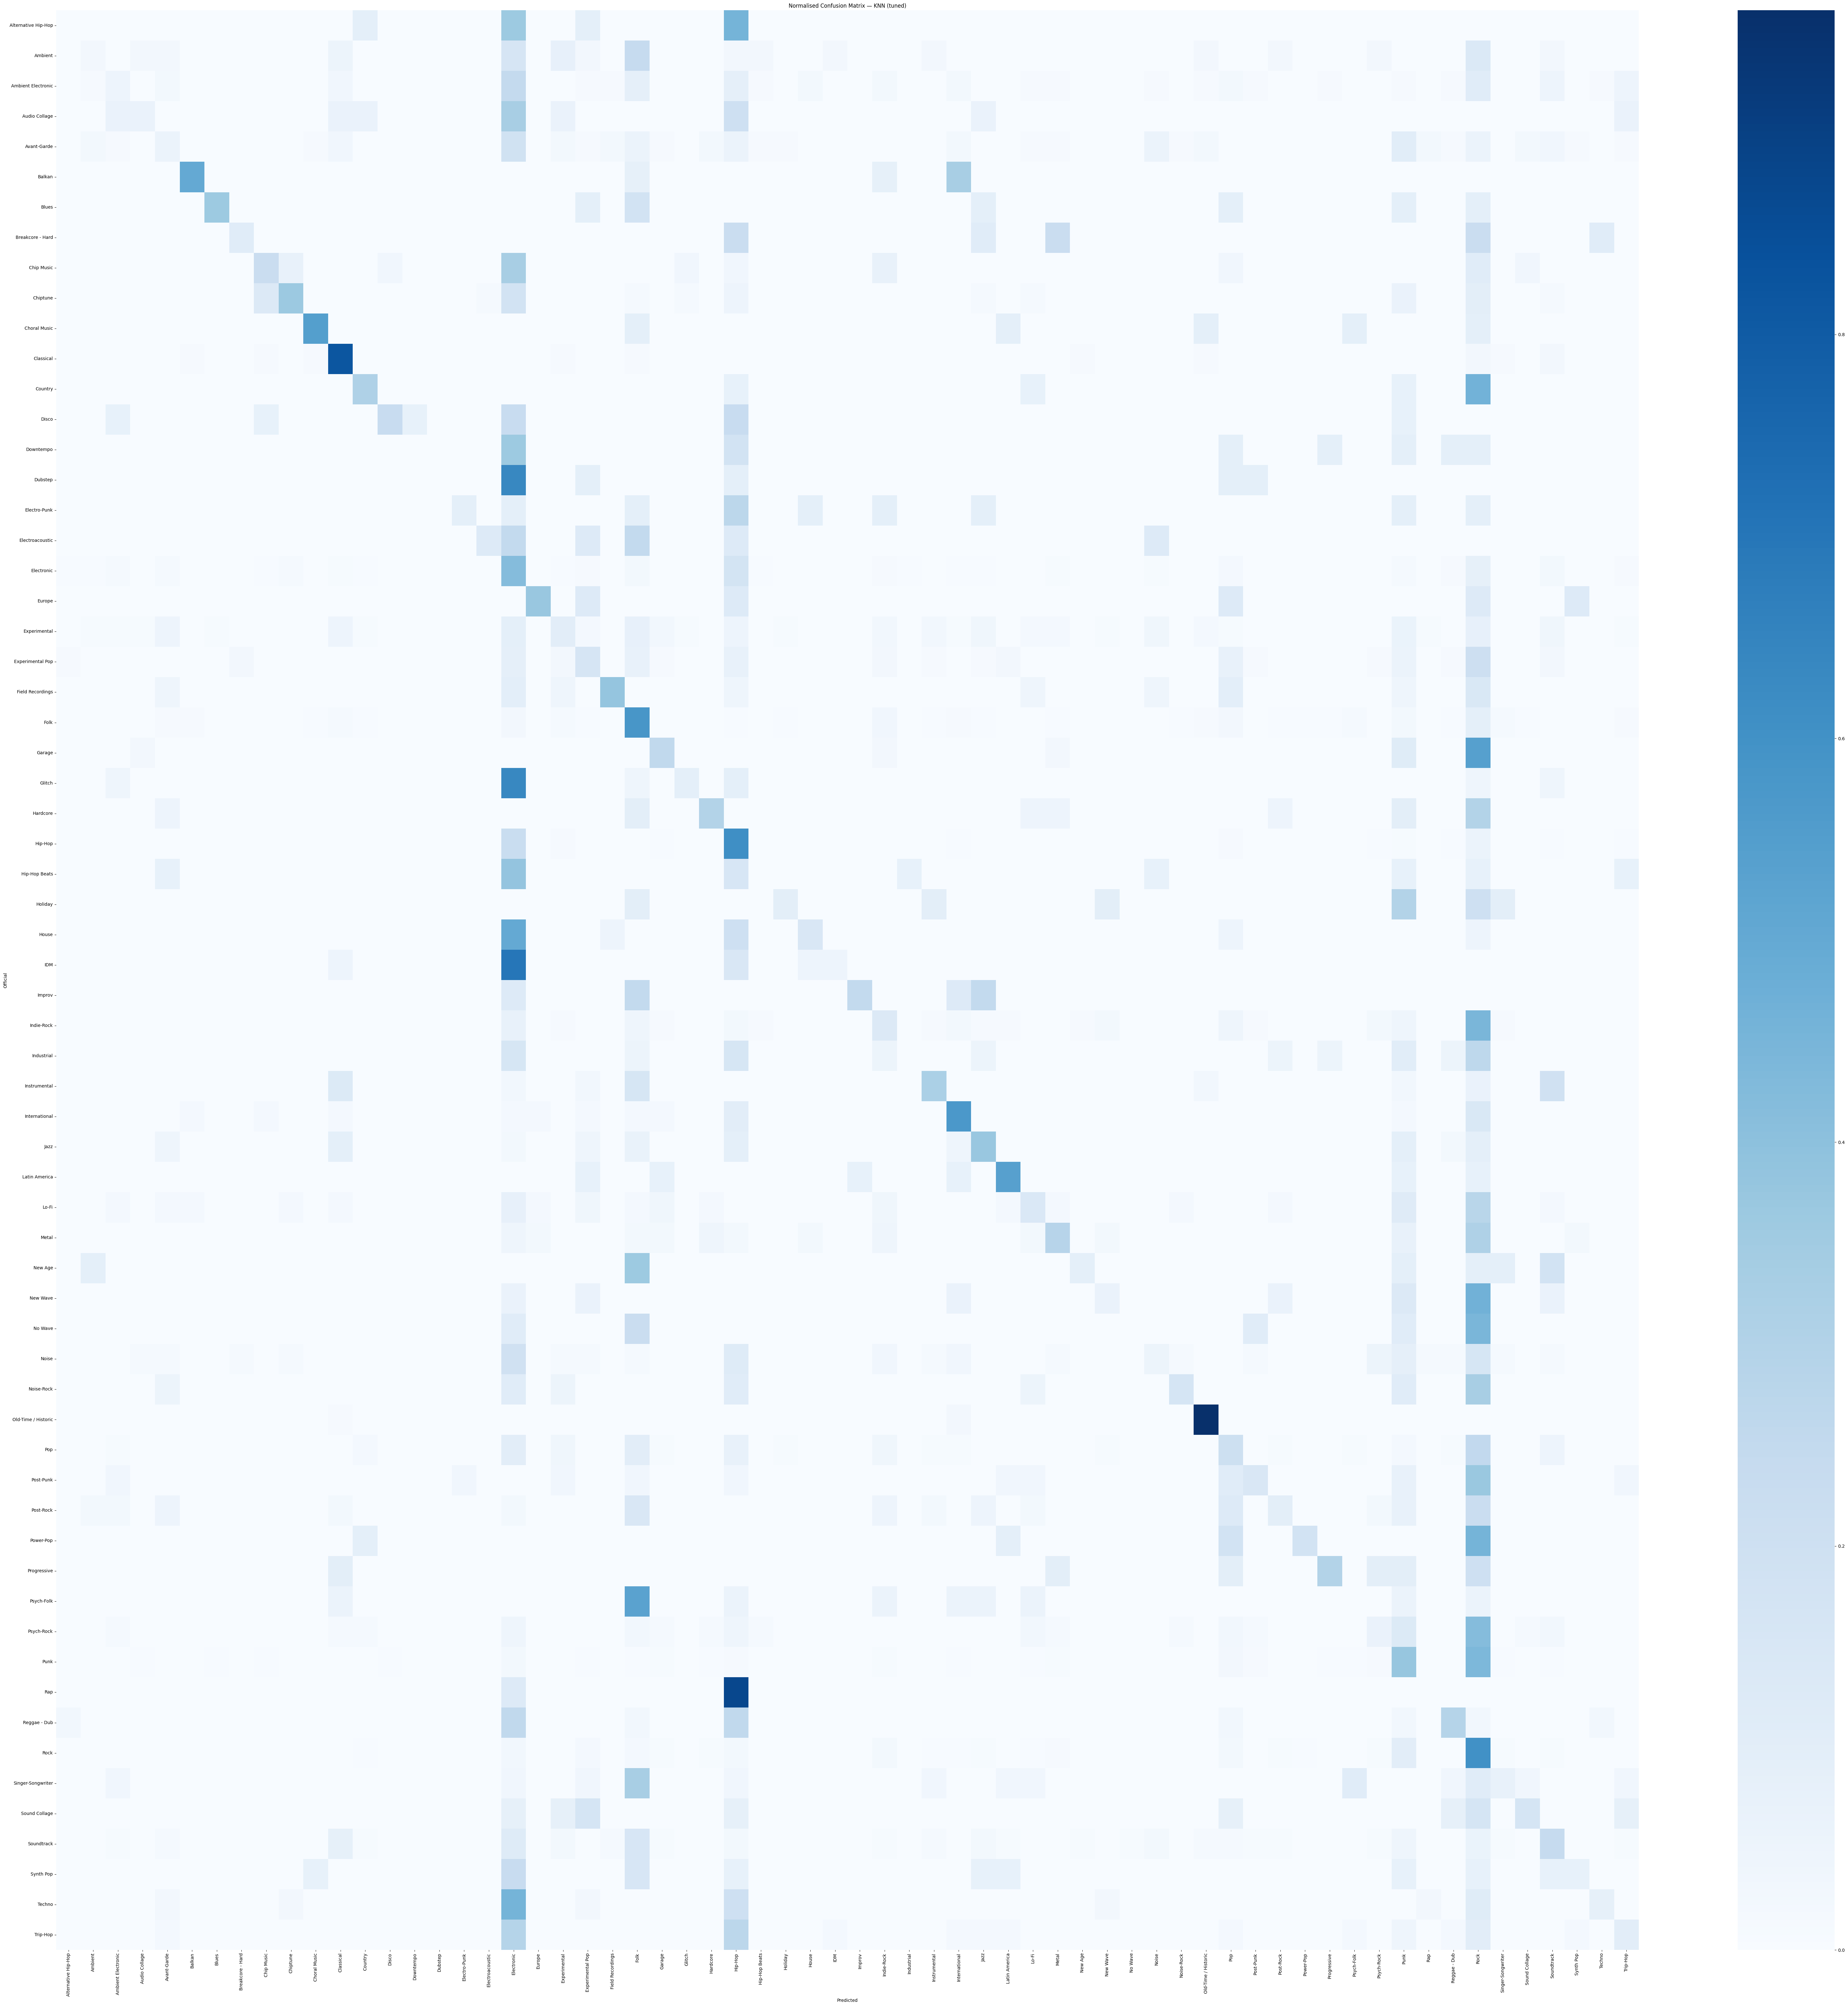

                     precision    recall  f1-score   support

Alternative Hip-Hop       0.00      0.00      0.00        11
            Ambient       0.09      0.03      0.04        37
 Ambient Electronic       0.15      0.05      0.07        81
      Audio Collage       0.12      0.07      0.09        15
        Avant-Garde       0.13      0.06      0.08        84
             Balkan       0.50      0.50      0.50        12
              Blues       0.67      0.36      0.47        11
   Breakcore - Hard       0.17      0.11      0.13         9
         Chip Music       0.29      0.22      0.25        27
           Chiptune       0.61      0.37      0.46        60
       Choral Music       0.60      0.55      0.57        11
          Classical       0.53      0.82      0.64        67
            Country       0.21      0.31      0.25        13
              Disco       0.43      0.23      0.30        13
          Downtempo       0.00      0.00      0.00        11
            Dubstep    

In [14]:
non_dummy       = results_df[results_df.Model != "Dummy"]
best_model_name = non_dummy.iloc[0]["Model"]
best_model      = fitted[best_model_name]
print("Selected best supervised model:", best_model_name)

yp = best_model.predict(X_val)
cm = confusion_matrix(y_val, yp)
cm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(max(8, n_classes), max(6, n_classes-1)))
sns.heatmap(cm, xticklabels=genre_names, yticklabels=genre_names,
            cmap="Blues", ax=ax)
ax.set_title(f"Normalised Confusion Matrix — {best_model_name}")
ax.set_xlabel("Predicted"); ax.set_ylabel("Official")
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "04_confusion_best.png"), dpi=150)
plt.show()

print(classification_report(y_val, yp, target_names=genre_names))

## 9. Neighbourhood Analysis

This is the explicit, standalone version of what KNN does implicitly. We build
a `NearestNeighbors` index on the training set (PCA space, cosine distance) and
for every validation track ask:

- **Neighbourhood purity** — what fraction of its k nearest neighbours share
  its official label? Low purity for a subgenre means that label does not
  correspond to a coherent acoustic region.
- **Neighbour vote** — what label does the neighbourhood majority suggest?
  Disagreement with the official label flags a relabelling candidate.

Separating retrieval (the index) from the decision (the vote) lets us vary k
independently of the tuned KNN classifier.

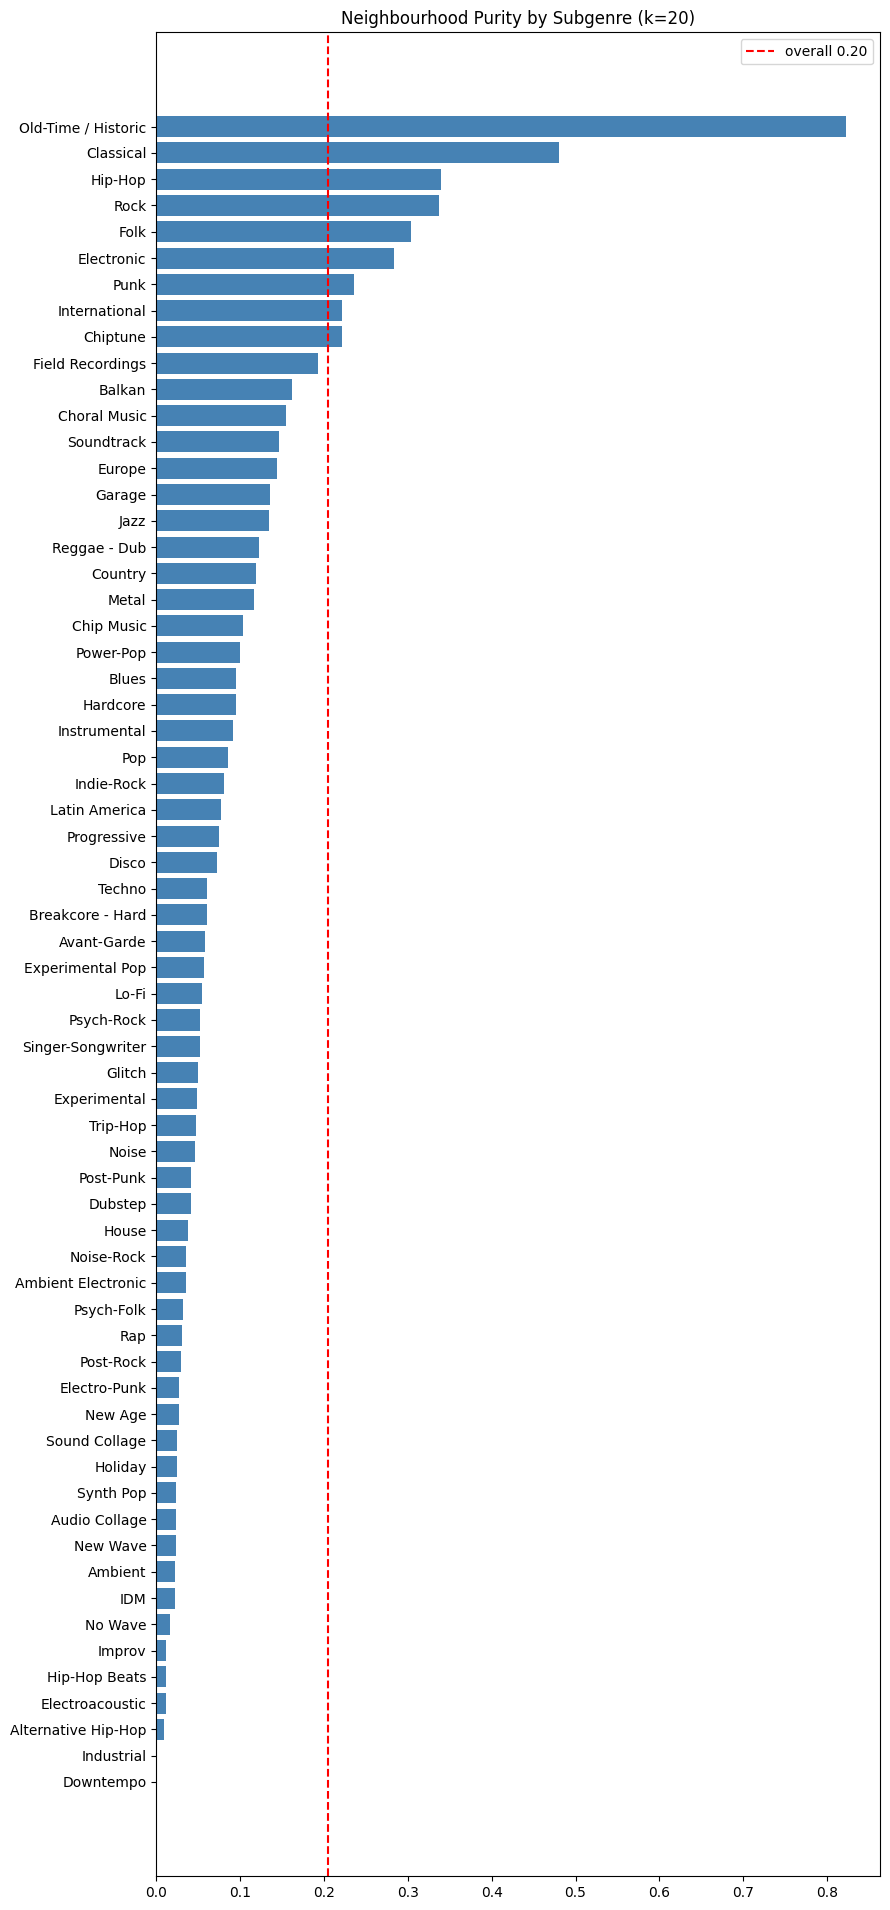

Overall purity: 0.205
Neighbour vote agreement with official: 35.20%


In [15]:
CKPT_NN = os.path.join(CKPT_DIR, f"nn_{SUBSET}.pkl")

if os.path.exists(CKPT_NN):
    purity_scores, voted_labels, nn_idx = joblib.load(CKPT_NN)
else:
    index = NearestNeighbors(n_neighbors=K_NEIGHBOURS, metric="cosine",
                             algorithm="brute", n_jobs=-1)
    index.fit(X_train_pca)
    _, nn_idx = index.kneighbors(X_val_pca)

    purity_scores = np.array([
        (y_train[row] == lbl).mean()
        for row, lbl in zip(nn_idx, y_val)])
    voted_labels = np.array([
        scipy_stats.mode(y_train[row], keepdims=True).mode[0]
        for row in nn_idx])

    joblib.dump((purity_scores, voted_labels, nn_idx), CKPT_NN)

rows = []
for g, name in enumerate(genre_names):
    m = y_val == g
    if m.sum():
        rows.append({"Subgenre": name,
                     "Mean purity": round(purity_scores[m].mean(), 3),
                     "N": int(m.sum())})
purity_df = pd.DataFrame(rows).sort_values("Mean purity", ascending=False)
purity_df.to_csv(os.path.join(RESULTS_DIR, "neighbourhood_purity.csv"), index=False)

fig, ax = plt.subplots(figsize=(9, max(5, n_classes*0.3)))
ps = purity_df.sort_values("Mean purity")
ax.barh(ps["Subgenre"], ps["Mean purity"], color="steelblue")
ax.axvline(purity_scores.mean(), color="red", ls="--",
           label=f"overall {purity_scores.mean():.2f}")
ax.set_title(f"Neighbourhood Purity by Subgenre (k={K_NEIGHBOURS})")
ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "05_neighbourhood_purity.png"), dpi=150)
plt.show()

print(f"Overall purity: {purity_scores.mean():.3f}")
print(f"Neighbour vote agreement with official: "
      f"{(voted_labels == y_val).mean():.2%}")

### Metric reference — how to read every number in this notebook

Use this as a lookup when interpreting results. Anchors are rough rules of
thumb for *this kind of task* (noisy, many-class audio data), not universal
thresholds.

**Supervised metrics**

| Metric | What it measures | How to read it here |
|---|---|---|
| **Macro F1** | Mean per-class F1, every subgenre weighted equally | Primary metric. With 100+ noisy subgenres, ~0.30–0.50 is a *realistic ceiling*, not a failure. The point is the ceiling's *level*, not beating a benchmark |
| **Weighted F1** | F1 weighted by class size | Always higher than macro F1 here; the gap between them quantifies how much the model leans on big classes |
| **ROC-AUC (OVR)** | Ranking quality, one-vs-rest | 0.5 = random, 1.0 = perfect. >0.7 means *some* genuine signal exists even if F1 is low |
| **Neighbourhood purity** | Fraction of a track's k nearest neighbours sharing its official label | 1.0 = label perfectly coherent locally; <0.3 = that subgenre's tracks are acoustically scattered → audit red flag |

**Clustering / agreement metrics** (all corrected for chance: 0 ≈ random)

| Metric | What it measures | How to read it here |
|---|---|---|
| **Silhouette** | Cluster cohesion vs separation (no labels used) | -1 to 1. >0.5 strong structure, 0.25–0.5 weak-but-real, <0.25 essentially no clean cluster structure. Used **only** to pick k |
| **AMI** | Shared information between clusters and official labels | 0 = independent, 1 = identical. **This is our headline number.** <0.25 = acoustic clusters barely reproduce the taxonomy (strong evidence for our claim); >0.5 = taxonomy is largely acoustically grounded |
| **ARI** | Pairwise agreement between the two partitions | Same 0–1 reading as AMI; reported alongside it as a robustness check — they should tell the same story |
| **NMI** | Like AMI but not chance-adjusted | Always ≥ AMI; included only for completeness |

**The single most important comparison:** AMI at the silhouette-optimal k,
read against where the silhouette peak sits relative to the official subgenre
count. Divergence between "the k the data wants" and "the official count",
combined with low AMI, is the project's central result.


## 10. Unsupervised Clustering — The Core Contribution

This is the heart of the project. We discard the official labels entirely and
ask: **what groupings does the acoustic data actually support?**

We cluster the PCA-reduced features with KMeans. The number of clusters is
**chosen by the data**, not set to match the official subgenre count — we sweep
`CLUSTER_RANGE` and pick the k with the best silhouette score. Forcing the
cluster count to equal the number of official subgenres would bias the
comparison toward agreement and undermine the whole argument.

**On metric choice (why silhouette with cosine distance is valid here):** we evaluate cluster quality with cosine distance, the same metric used by the KNN classifier and the neighbourhood index, so the geometry is consistent across every unsupervised component — the clusters are judged in the exact space the rest of the audit operates in.

### 10.1 Choosing the number of clusters — silhouette vs AMI

We select the number of clusters by **silhouette score**, a purely
label-free measure of how cohesive and well-separated the clusters are. This
is the principled choice: the data, not the official taxonomy, decides the
grouping granularity.

But we also compute a second curve on the same range — the **Adjusted Mutual
Information (AMI)** between each candidate clustering and the official subgenre
labels. Plotting these together is itself a result, not just a diagnostic:

- The **silhouette peak** tells us the number of clusters the acoustic data
  *naturally* wants.
- The **AMI curve** tells us how closely each clustering reproduces the
  official taxonomy.

The interesting outcome is **divergence**. If silhouette peaks at a k that is
very different from the official subgenre count, *and* AMI stays low across the
whole range, that is direct evidence that the acoustic structure does not align
with the human taxonomy at any granularity — the strongest possible form of our
central claim. If instead AMI rises toward the official count, the taxonomy is
at least partially acoustically grounded. Either way, the relationship between
the two curves is the headline diagnostic.

We pick `best_k` strictly by silhouette (the data-driven criterion) and report
where AMI sits at that k, rather than choosing k to maximise agreement — doing
the latter would bias the entire analysis toward the conclusion we are testing.


k=5    silhouette=0.7655  AMI=0.0019
k=10   silhouette=0.7808  AMI=0.0033
k=15   silhouette=0.7926  AMI=0.0037
k=20   silhouette=0.7940  AMI=0.0039
k=25   silhouette=0.2946  AMI=0.0320
k=30   silhouette=0.1871  AMI=0.1006
k=35   silhouette=0.0659  AMI=0.1384
k=40   silhouette=0.0703  AMI=0.1350
k=45   silhouette=0.0369  AMI=0.1363
k=50   silhouette=0.0483  AMI=0.1380
k=55   silhouette=0.0425  AMI=0.1429
k=60   silhouette=0.0670  AMI=0.1374

*** OVERRIDE: silhouette chose k=20, forcing k=35 for biased exploration ***


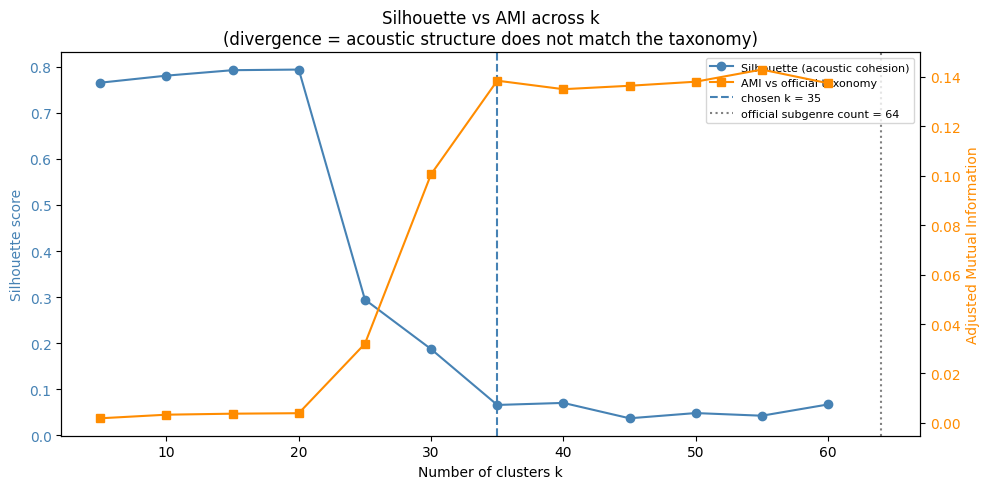

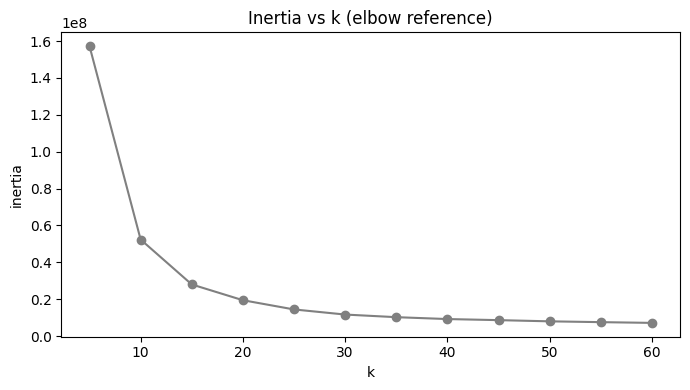


Chosen k             = 35
AMI at that k        = 0.138
Official subgenre count = 64
Max AMI over range   = 0.143 (at k=55)


In [ ]:
CKPT_KSEL = os.path.join(CKPT_DIR, f"ksel_{SUBSET}.pkl")

FORCE_K = None   # biased exploration override. Set to None for the principled silhouette choice. 

if FORCE_K is None and os.path.exists(CKPT_KSEL):
    sil_scores, ami_scores, inertias, best_k = joblib.load(CKPT_KSEL)
else:
    sil_scores, ami_scores, inertias = {}, {}, {}
    for k in CLUSTER_RANGE:
        km  = KMeans(n_clusters=k, random_state=SEED, n_init=10)
        lab = km.fit_predict(X_train_pca)
        # DEV sample_size 3000 keeps silhouette fast on Small.
        # FULL: raise to min(20000, len(X_train_pca)) for a more
        # stable estimate on the full dataset (if you have the hardware).
        sil_scores[k] = silhouette_score(
            X_train_pca, lab, metric="cosine",
            sample_size=min(3000, len(X_train_pca)),  # FULL: min(20000, ...)
            random_state=SEED)
        # AMI of this clustering against the OFFICIAL labels (train split)
        ami_scores[k] = adjusted_mutual_info_score(y_train, lab)
        inertias[k]   = km.inertia_
        print(f"k={k:<4} silhouette={sil_scores[k]:.4f}  "
              f"AMI={ami_scores[k]:.4f}")
    # best_k chosen by SILHOUETTE only 
    best_k = max(sil_scores, key=sil_scores.get)
    if FORCE_K is not None:
        print(f"\n*** OVERRIDE: silhouette chose k={best_k}, "
              f"forcing k={FORCE_K} for biased exploration ***")
        best_k = FORCE_K
    joblib.dump((sil_scores, ami_scores, inertias, best_k), CKPT_KSEL)

ks       = list(sil_scores)
n_off    = n_classes  # number of official subgenres, for reference line

# --- combined silhouette vs AMI plot (the headline diagnostic) ---
fig, ax1 = plt.subplots(figsize=(10, 5))

l1, = ax1.plot(ks, [sil_scores[k] for k in ks], "o-",
               color="steelblue", label="Silhouette (acoustic cohesion)")
ax1.set_xlabel("Number of clusters k")
ax1.set_ylabel("Silhouette score", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.axvline(best_k, color="steelblue", ls="--",
            label=f"chosen k = {best_k}")

ax2 = ax1.twinx()
l2, = ax2.plot(ks, [ami_scores[k] for k in ks], "s-",
               color="darkorange", label="AMI vs official taxonomy")
ax2.set_ylabel("Adjusted Mutual Information", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

ax1.axvline(n_off, color="grey", ls=":",
            label=f"official subgenre count = {n_off}")

lines = [l1, l2,
         plt.Line2D([0], [0], color="steelblue", ls="--"),
         plt.Line2D([0], [0], color="grey", ls=":")]
labels = ["Silhouette (acoustic cohesion)",
          "AMI vs official taxonomy",
          f"chosen k = {best_k}",
          f"official subgenre count = {n_off}"]
ax1.legend(lines, labels, loc="upper right", fontsize=8)
ax1.set_title("Silhouette vs AMI across k\n"
              "(divergence = acoustic structure does not match the taxonomy)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "06_silhouette_vs_ami.png"), dpi=150)
plt.show()

# --- inertia elbow kept as a secondary reference ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ks, [inertias[k] for k in ks], "o-", color="grey")
ax.set_title("Inertia vs k (elbow reference)")
ax.set_xlabel("k"); ax.set_ylabel("inertia")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "06b_inertia_elbow.png"), dpi=150)
plt.show()

print(f"\nChosen k             = {best_k}")
print(f"AMI at that k        = {ami_scores[best_k]:.3f}")
print(f"Official subgenre count = {n_off}")
print(f"Max AMI over range   = {max(ami_scores.values()):.3f} "
      f"(at k={max(ami_scores, key=ami_scores.get)})")

### 10.2 Fit the final clustering

We fit KMeans with the selected k on the training set and assign clusters to
the validation tracks. These cluster IDs are the **new, data-driven label
system** — derived with zero knowledge of the official taxonomy.

In [30]:
kmeans = KMeans(n_clusters=best_k, random_state=SEED, n_init=10)
cluster_train = kmeans.fit_predict(X_train_pca)
cluster_val   = kmeans.predict(X_val_pca)
print(f"KMeans fitted with k={best_k}")
print(f"Cluster sizes (val): "
      f"{np.bincount(cluster_val, minlength=best_k).tolist()}")

KMeans fitted with k=35
Cluster sizes (val): [267, 3, 0, 6, 0, 2, 0, 37, 1, 3, 0, 0, 1, 0, 11, 1, 0, 1, 0, 0, 4, 0, 77, 101, 13, 0, 8, 1050, 16, 2, 0, 1167, 10, 0, 736]


### 10.3 Do the clusters agree with the official taxonomy?

We compare the data-driven clusters against the official subgenre labels using
label-free agreement metrics:

- **Adjusted Mutual Information (AMI)** — shared information between the two
  partitions, corrected for chance. 0 = independent, 1 = identical.
- **Adjusted Rand Index (ARI)** — pairwise agreement, corrected for chance.

A *low* AMI/ARI is the headline result: it means the acoustic data does not
naturally reproduce the official taxonomy — the labels are, to a measurable
degree, not grounded in sound.

In [31]:
ami = adjusted_mutual_info_score(y_val, cluster_val)
ari = adjusted_rand_score(y_val, cluster_val)
nmi = normalized_mutual_info_score(y_val, cluster_val)

print(f"Adjusted Mutual Information : {ami:.3f}")
print(f"Adjusted Rand Index        : {ari:.3f}")
print(f"Normalized Mutual Info     : {nmi:.3f}")

interp = ("strong" if ami > 0.5 else "moderate" if ami > 0.25 else "weak")
print(f"\n-> {interp} correspondence between acoustic clusters and the "
      f"official subgenre taxonomy.")

pd.DataFrame([{"AMI": round(ami,3), "ARI": round(ari,3),
               "NMI": round(nmi,3), "k": best_k}]
            ).to_csv(os.path.join(RESULTS_DIR, "cluster_agreement.csv"),
                     index=False)

Adjusted Mutual Information : 0.142
Adjusted Rand Index        : 0.072
Normalized Mutual Info     : 0.174

-> weak correspondence between acoustic clusters and the official subgenre taxonomy.


### 10.4 Cluster composition — where does the taxonomy break?

For each cluster we look at which official subgenres land in it. Two
diagnostic patterns:

- **One cluster, many subgenres** → those subgenres are acoustically
  indistinguishable; the taxonomy may *over-fragment* a single style.
- **One subgenre, many clusters** → that label is acoustically incoherent; it
  spans several distinct sounds.

This heatmap is the central figure of the project.

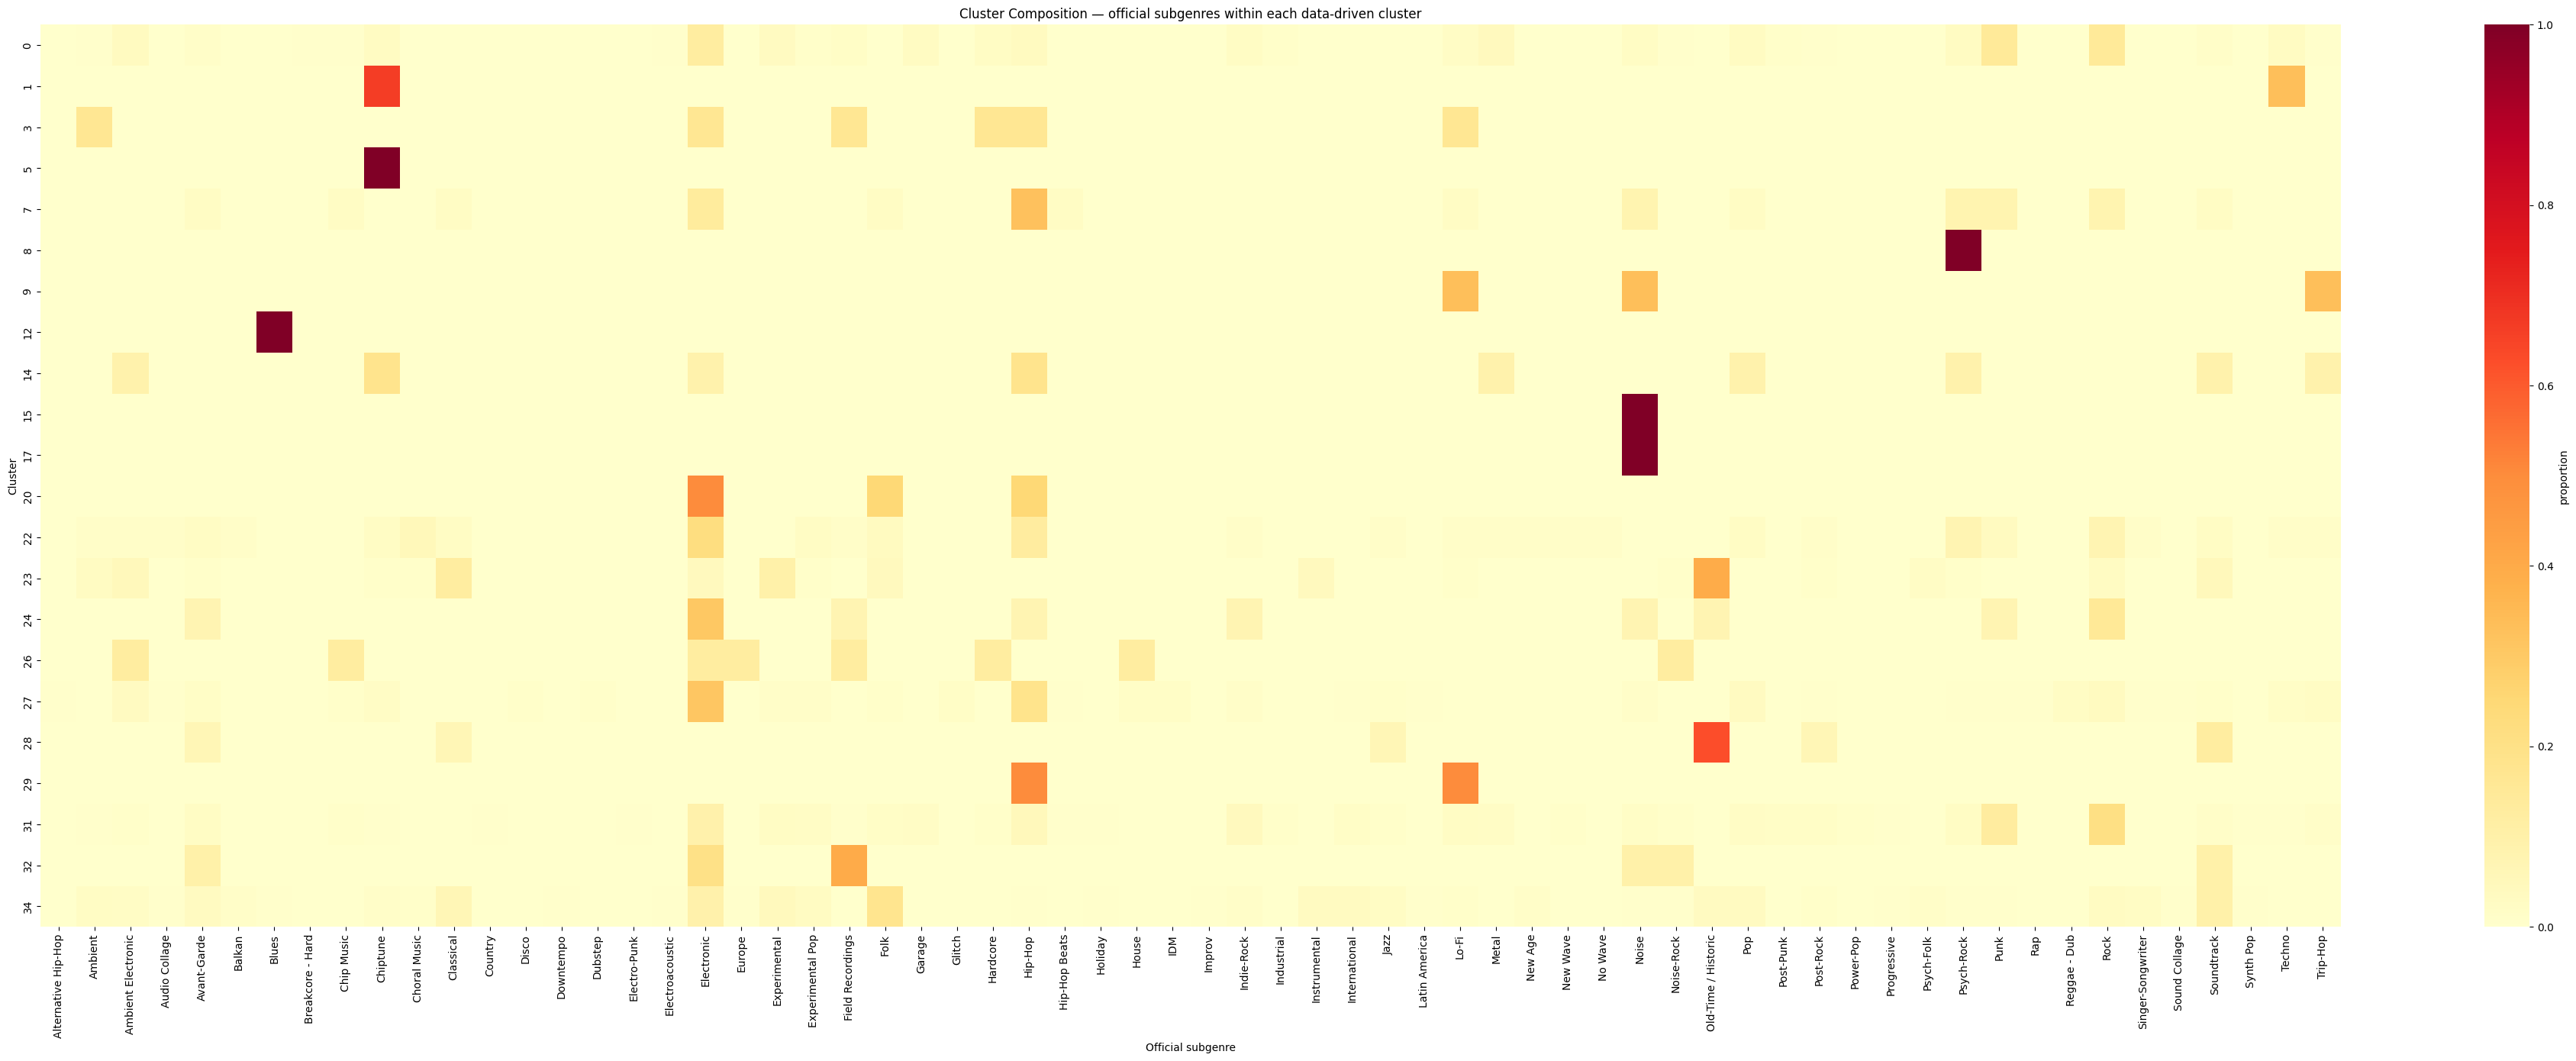

Most acoustically fragmented official subgenres (appear in many clusters):
row_0
Electronic            13
Hip-Hop               11
Noise                 10
Lo-Fi                 10
Avant-Garde           10
Soundtrack            10
Chiptune               9
Psych-Rock             9
Field Recordings       9
Ambient Electronic     8


In [32]:
comp = pd.crosstab(cluster_val, le.inverse_transform(y_val),
                   normalize="index")
fig, ax = plt.subplots(figsize=(max(10, n_classes*0.6),
                                max(6, best_k*0.4)))
sns.heatmap(comp, cmap="YlOrRd", ax=ax, cbar_kws={"label": "proportion"})
ax.set_title("Cluster Composition — official subgenres within each "
             "data-driven cluster")
ax.set_xlabel("Official subgenre"); ax.set_ylabel("Cluster")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "07_cluster_composition.png"), dpi=150)
plt.show()

# subgenres spread across the most clusters = least acoustically coherent
spread = (pd.crosstab(le.inverse_transform(y_val), cluster_val) > 0).sum(axis=1)
print("Most acoustically fragmented official subgenres "
      "(appear in many clusters):")
print(spread.sort_values(ascending=False).head(10).to_string())

In [33]:
# --- Auto-generate descriptive cluster names ---

def name_cluster(cluster_id, comp_tab, X_train_orig, cluster_labels,
                 feature_names, top_n_genres=2, top_n_features=3):
    row = comp_tab.loc[cluster_id]
    top_genres = row.sort_values(ascending=False).head(top_n_genres).index.tolist()

    cluster_mask = cluster_labels == cluster_id
    cluster_means = X_train_orig[cluster_mask].mean(axis=0)
    global_means  = X_train_orig.mean(axis=0)
    diff = np.abs(cluster_means - global_means)

    top_idx = pd.Series(diff).sort_values(ascending=False).head(top_n_features).index.tolist()
    top_features = [feature_names[i] for i in top_idx]

    genre_part   = " / ".join(str(g) for g in top_genres)
    feature_part = " + ".join(str(f).split("_")[0] for f in top_features)
    return f"{genre_part} [{feature_part}]"

X_train_scaled_full = scaler.transform(X_train)

cluster_names = {}
for cid in comp.index:
    cluster_names[cid] = name_cluster(
        cid, comp, X_train_scaled_full, cluster_train, feature_names)
    print(f"Cluster {cid}: {cluster_names[cid]}")

pd.DataFrame([{"cluster_id": k, "suggested_name": v}
              for k, v in cluster_names.items()]
            ).to_csv(os.path.join(RESULTS_DIR, "cluster_names.csv"), index=False)

Cluster 0: Rock / Punk [rmse + chroma + chroma]
Cluster 1: Chiptune / Techno [rmse + spectral + spectral]
Cluster 3: Hardcore / Lo-Fi [rmse + spectral + spectral]
Cluster 5: Chiptune / Alternative Hip-Hop [rmse + mfcc + mfcc]
Cluster 7: Hip-Hop / Electronic [rmse + spectral + spectral]
Cluster 8: Psych-Rock / Alternative Hip-Hop [rmse + spectral + spectral]
Cluster 9: Trip-Hop / Lo-Fi [rmse + spectral + spectral]
Cluster 12: Blues / Alternative Hip-Hop [rmse + spectral + spectral]
Cluster 14: Chiptune / Hip-Hop [rmse + spectral + spectral]
Cluster 15: Noise / Alternative Hip-Hop [rmse + spectral + spectral]
Cluster 17: Noise / Alternative Hip-Hop [rmse + spectral + spectral]
Cluster 20: Electronic / Hip-Hop [rmse + spectral + spectral]
Cluster 22: Electronic / Hip-Hop [rmse + spectral + spectral]
Cluster 23: Old-Time / Historic / Classical [rmse + spectral + spectral]
Cluster 24: Electronic / Rock [rmse + spectral + spectral]
Cluster 26: Electronic / Ambient Electronic [rmse + spectral

## 11. Three-Way Comparison and Relabelling Candidates

We now hold up three views of every validation track side by side:

1. **Official** subgenre label (human taxonomy)
2. **Classifier** prediction (best supervised model — the "learnable" view)
3. **Neighbour vote** (local acoustic consensus)

plus the **cluster** assignment as the global data-driven grouping.

- All three agree → high-confidence, acoustically coherent label.
- Classifier and neighbour agree but differ from official → **relabelling
  candidate**: the acoustics consistently point elsewhere.
- All disagree → genuinely ambiguous / hybrid track.

These categories, together with the cluster composition above, are the
concrete evidence for the report's claims.

In [34]:
yp_best = best_model.predict(X_val)
comp_df = pd.DataFrame({
    "official":       le.inverse_transform(y_val),
    "classifier":     le.inverse_transform(yp_best),
    "neighbour_vote": le.inverse_transform(voted_labels),
    "cluster":        cluster_val})
comp_df["cluster_name"] = comp_df["cluster"].map(cluster_names)

agree   = comp_df.query("official == classifier == neighbour_vote")
relabel = comp_df.query("classifier == neighbour_vote and official != classifier")
ambig   = comp_df.query("official != classifier and classifier != neighbour_vote")

n = len(comp_df)
print(f"Full agreement       : {len(agree):>5} ({len(agree)/n:.1%})")
print(f"Relabelling candidate: {len(relabel):>5} ({len(relabel)/n:.1%})")
print(f"Fully ambiguous      : {len(ambig):>5} ({len(ambig)/n:.1%})")

relabel.to_csv(os.path.join(RESULTS_DIR, "relabelling_candidates.csv"))

patterns = (relabel.groupby(["official", "classifier"]).size()
            .reset_index(name="count")
            .sort_values("count", ascending=False).head(15))
patterns.to_csv(os.path.join(RESULTS_DIR, "relabelling_patterns.csv"),
                index=False)
print("\nTop official -> suggested relabelling patterns:")
print(patterns.to_string(index=False))

Full agreement       :   910 (25.9%)
Relabelling candidate:  1000 (28.4%)
Fully ambiguous      :  1265 (36.0%)

Top official -> suggested relabelling patterns:
          official classifier  count
              Punk       Rock     76
           Hip-Hop Electronic     44
        Electronic    Hip-Hop     39
        Indie-Rock       Rock     35
        Electronic       Rock     27
        Psych-Rock       Rock     19
Ambient Electronic Electronic     17
               Pop       Rock     17
            Techno Electronic     15
        Soundtrack       Folk     15
            Garage       Rock     15
               IDM Electronic     13
            Glitch Electronic     12
             Lo-Fi       Rock     11
       Avant-Garde Electronic     11


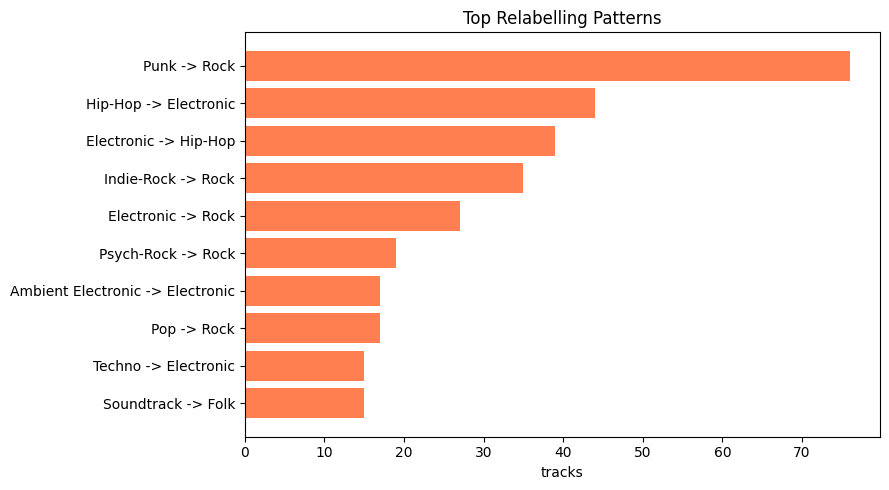

In [35]:
top = patterns.head(10)
lbl = [f"{r.official} -> {r.classifier}" for r in top.itertuples()]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(lbl[::-1], top["count"].values[::-1], color="coral")
ax.set_xlabel("tracks"); ax.set_title("Top Relabelling Patterns")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "08_relabelling_patterns.png"), dpi=150)
plt.show()

## 12. Interpretation — Which Acoustic Features Drive the Audit

We need interpretability in the **original feature space**, not PCA components
(which are meaningless to a reader). Two complementary tools:

- **Permutation importance** — model-agnostic, runs through the full pipeline,
  reports importance of original features. Works for any best model.
- **SHAP (TreeExplainer)** — exact and fast for tree models. We run it **only**
  if the best model is tree-based, because the RF/GB pipelines deliberately
  omit PCA, so SHAP values land directly on interpretable audio features.
  SHAP on a PCA pipeline would explain components, not features — which is why
  permutation importance is the safe default.

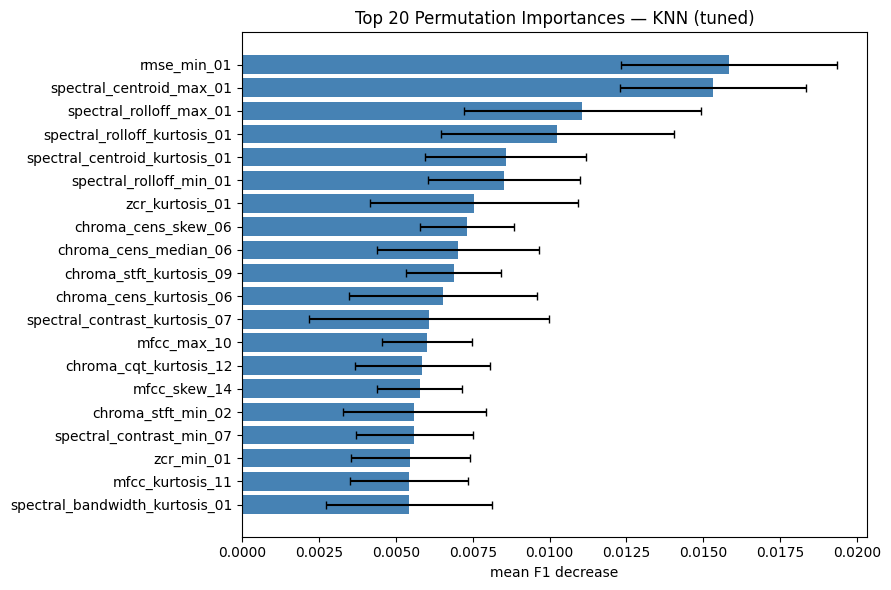

In [ ]:
# n_repeats=10 is fine for the full run on a cluster. Lower to 5 only
# if you need a fast Small-subset pass (DEV: 5  FULL: 10).
perm = permutation_importance(best_model, X_val, y_val,
                              n_repeats=10,  # DEV: 5   FULL: 10
                              random_state=SEED, scoring="f1_macro",
                              n_jobs=-1)
perm_df = (pd.DataFrame({"feature": feature_names,
                         "importance": perm.importances_mean,
                         "std": perm.importances_std})
           .sort_values("importance", ascending=False))
perm_df.to_csv(os.path.join(RESULTS_DIR, "permutation_importance.csv"),
               index=False)

top20 = perm_df.head(20)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top20.feature[::-1], top20.importance[::-1],
        xerr=top20["std"][::-1], color="steelblue", capsize=3)
ax.set_title(f"Top 20 Permutation Importances — {best_model_name}")
ax.set_xlabel("mean F1 decrease")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "09_permutation_importance.png"), dpi=150)
plt.show()

In [26]:
if any(t in best_model_name for t in ("Random Forest", "Gradient Boosting")):
    clf = best_model.named_steps["clf"]
    sc  = best_model.named_steps["scaler"]
    SHAP_N = 500
    Xs = sc.transform(X_val)[:SHAP_N]
    expl = shap.TreeExplainer(clf)
    sv = expl.shap_values(Xs)

    # sv shape is (n_samples, n_features, n_classes) in some shap versions
    sv_arr = np.array(sv)
    print(f"sv_arr raw shape: {sv_arr.shape}")

    if sv_arr.ndim == 3:
        if sv_arr.shape[2] == len(feature_names):
            # (n_samples, n_classes, n_features) or (n_samples, n_features, n_classes)
            mean_abs = np.abs(sv_arr).mean(axis=(0, 1))
        elif sv_arr.shape[1] == len(feature_names):
            mean_abs = np.abs(sv_arr).mean(axis=(0, 2))
        else:
            mean_abs = np.abs(sv_arr).mean(axis=(0, 1))
    elif sv_arr.ndim == 2:
        mean_abs = np.abs(sv_arr).mean(axis=0)

    print(f"mean_abs shape: {mean_abs.shape}, feature_names: {len(feature_names)}")

    sd = (pd.DataFrame({"feature": feature_names, "shap": mean_abs})
          .sort_values("shap", ascending=False).head(20))
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.barh(sd.feature[::-1], sd.shap[::-1], color="coral")
    ax.set_title(f"SHAP Feature Importance — {best_model_name}")
    ax.set_xlabel("mean |SHAP|")
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, "10_shap_importance.png"), dpi=150)
    plt.show()
else:
    print(f"Best model is {best_model_name} — permutation importance covers interpretation.")

Best model is KNN (tuned) — permutation importance covers interpretation.


## 13. Final Test Evaluation

The held-out test set is used **exactly once**, here, on the single selected
model. We do not compare multiple models on test — that would be a form of
test-set optimisation. This number is the honest estimate of how well the
acoustic features predict the official taxonomy on unseen data.

In [27]:
yt = best_model.predict(X_test)
try:
    troc = roc_auc_score(y_test, best_model.predict_proba(X_test),
                         multi_class="ovr", average="macro")
except Exception:
    troc = np.nan

print(f"TEST  macro F1    : {f1_score(y_test, yt, average='macro'):.4f}")
print(f"TEST  weighted F1 : {f1_score(y_test, yt, average='weighted'):.4f}")
print(f"TEST  ROC-AUC     : {troc:.4f}")
print()
print(classification_report(y_test, yt, target_names=genre_names))

pd.DataFrame([{
    "model": best_model_name,
    "test_f1_macro": round(f1_score(y_test, yt, average="macro"), 4),
    "test_f1_weighted": round(f1_score(y_test, yt, average="weighted"), 4),
    "test_roc_auc": round(troc, 4)
}]).to_csv(os.path.join(RESULTS_DIR, "test_results.csv"), index=False)

TEST  macro F1    : 0.2238
TEST  weighted F1 : 0.3287
TEST  ROC-AUC     : 0.6861

                     precision    recall  f1-score   support

Alternative Hip-Hop       0.00      0.00      0.00        11
            Ambient       0.29      0.11      0.16        37
 Ambient Electronic       0.38      0.11      0.17        81
      Audio Collage       0.10      0.06      0.08        16
        Avant-Garde       0.18      0.10      0.12        84
             Balkan       0.50      0.58      0.54        12
              Blues       0.00      0.00      0.00        11
   Breakcore - Hard       0.00      0.00      0.00         9
         Chip Music       0.27      0.15      0.19        27
           Chiptune       0.39      0.18      0.25        60
       Choral Music       0.67      0.55      0.60        11
          Classical       0.62      0.67      0.64        67
            Country       0.19      0.31      0.24        13
              Disco       0.30      0.23      0.26        13
  

### The argument in one chain — read this before the presentation

Any team member should be able to state the project's logic in 30 seconds.
Here it is as a single causal chain:

1. **We frame classification as measurement, not the goal.** We train models
   to predict official subgenres *only* to measure how acoustically learnable
   that taxonomy is.

2. **The supervised ceiling is [low / moderate]** (best test macro F1 ≈
   `[your number]`). Because we used strong models with proper tuning and no
   leakage, a low ceiling cannot be blamed on modelling — it means the labels
   themselves are only weakly determined by how the music sounds.

3. **An independent, label-free method agrees.** KMeans, given *no* access to
   the official labels, produces clusters whose AMI with the taxonomy is
   `[your number]`. Two methods reaching the same conclusion from opposite
   directions (supervised vs unsupervised) makes the finding robust, not a
   modelling artefact.

4. **We can point to *where* it breaks.** The cluster-composition heatmap and
   relabelling-pattern table identify specific subgenres that are
   over-fragmented (one acoustic style split across many labels) or incoherent
   (one label spread across many clusters) — e.g. `[your examples]`.

5. **Therefore:** the official FMA subgenre taxonomy is, to a measurable
   degree, **not grounded in acoustic similarity**. We do not claim our
   clusters are the "true" genres — only that the human taxonomy and the
   acoustic structure demonstrably diverge, with concrete, reproducible
   evidence for where and how.

Each link in this chain maps to a section: 2→§6, 3→§10.3, 4→§10.4 & §11,
5→conclusion. If asked "what is your project about?" answer with this chain,
not with model scores.

---


## 14. Reflection, Limitations, and Conclusions

*(Fill the bracketed parts with your actual numbers before submission.)*

### What we found

The supervised ceiling (best test macro F1 ≈ **[your number]**) shows the
official subgenre taxonomy is **[weakly / moderately]** predictable from
acoustic features alone. The clustering analysis reinforces this: AMI between
the data-driven clusters and the official labels is **[your number]**,
indicating the acoustic structure **[does / does not]** naturally reproduce the
taxonomy.

The cluster-composition heatmap and the relabelling patterns identify the
specific failure points — subgenres such as **[examples from your run]** are
acoustically fragmented (spread across many clusters) or collapse together
(many subgenres in one cluster). These are concrete, evidence-backed
relabelling candidates rather than speculation.

### Why the supervised score being low is a *result*, not a failure

We deliberately framed classification as a measurement device. A ceiling well
below perfect is the quantitative core of our argument: it *measures* how much
the official taxonomy diverges from acoustic reality. Combined with the
unsupervised clustering, this triangulates the claim from two independent
directions.

### Limitations

- FMA skews toward independent / Creative-Commons music; major-label pop and
  hip-hop are under-represented, so conclusions generalise to this catalogue,
  not all music.
- We take only the first (most specific) genre ID per track; many tracks are
  genuinely multi-genre and we simplify this.
- Genre is a cultural construct. We claim only *acoustic incoherence*, never
  that our clusters are the "true" genres.
- KMeans assumes roughly convex, similarly-scaled clusters in PCA space; a
  density-based alternative (e.g. HDBSCAN) is left as future work.

### Group process

*(Division of labour, tools — Colab / GitHub / shared notebook — what worked,
what you would change. Commit regularly so contribution is traceable.)*

### Conclusion

We set out not to classify genres but to interrogate a genre taxonomy. Using
classification as a ruler and clustering as an independent witness, we showed
**[summarise your headline finding in one sentence]**.